# 02 · Modelo: Regresión logística

**Proyecto Final — Machine Learning y Deep Learning**

Este notebook se centra en **un solo modelo**: un modelo **lineal** sencillo y muy interpretable; nuestra línea base. Sigue la misma estructura que el resto de notebooks de modelo, para poder compararlos con facilidad.

> 📖 Términos técnicos explicados en `docs/glosario.md`. El análisis de los datos está en [`01_eda.ipynb`](01_eda.ipynb); la comparación de todos los modelos, en [`07_comparativa_modelos.ipynb`](07_comparativa_modelos.ipynb).

## 1. Cómo funciona

A pesar de su nombre, la **regresión logística** es un *clasificador*. Calcula una **suma ponderada** de las variables (como una recta o un plano) y la pasa por la función **sigmoide**, que la convierte en una **probabilidad** entre 0 y 1. Durante el entrenamiento aprende los **pesos** que mejor separan las clases.

Es un modelo **lineal**: su frontera de decisión es una línea/plano recto. Por eso es rápido e interpretable (cada coeficiente indica cuánto y en qué dirección empuja una variable hacia "cancela"), pero no captura por sí solo relaciones complejas o curvas.

## 2. Los datos

Usamos el **mismo preprocesado compartido** por todos los modelos (`src/preprocessing.py`): imputación de huecos, estandarización de las numéricas y *one-hot* de las categóricas. El análisis de los datos está en [`01_eda.ipynb`](01_eda.ipynb). Cargamos y dividimos en train/test (estratificado, semilla fija) con `load_and_prepare()`.

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay)
from src import config
from src.data_loader import load_and_prepare
from src.preprocessing import build_preprocessor

X_train, X_test, y_train, y_test = load_and_prepare()
print('Entrenamiento:', X_train.shape, '| Prueba:', X_test.shape)

def evaluar(pipe, etiqueta):
    """Imprime las métricas de test del pipeline y devuelve su ROC-AUC."""
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    m = dict(accuracy=accuracy_score(y_test, pred), precision=precision_score(y_test, pred),
             recall=recall_score(y_test, pred), f1=f1_score(y_test, pred),
             roc_auc=roc_auc_score(y_test, proba))
    print(f"{etiqueta:12s} | " + ' | '.join(f'{k}={v:.4f}' for k, v in m.items()))
    return m['roc_auc']

Entrenamiento: (95368, 28) | Prueba: (23842, 28)


## 3. Los hiperparámetros: ¿qué controla cada uno?

Los **hiperparámetros** son los ajustes que fijamos *antes* de entrenar (no se aprenden de los datos). Estos son los principales de este modelo:

| Hiperparámetro | Qué controla |
|---|---|
| `C` | Inverso de la **regularización**. `C` alto → poca regularización (puede sobreajustar); `C` bajo → modelo más simple y suave. |
| `penalty` | Tipo de regularización (`l2` por defecto): penaliza pesos grandes para evitar el sobreajuste. |
| `class_weight` | Si `'balanced'`, da más peso a la clase minoritaria (ver el notebook de balanceo). |
| `solver` | Algoritmo de optimización que ajusta los pesos. |
| `max_iter` | Nº máximo de iteraciones del optimizador (que llegue a converger). |

## 4. Entrenamiento y evaluación (parámetros base)

Entrenamos el modelo con los hiperparámetros base y lo evaluamos sobre el conjunto de prueba (datos que no vio al entrenar).

In [2]:
# Pipeline = preprocesado + modelo (con los hiperparámetros base del proyecto)
from sklearn.linear_model import LogisticRegression
modelo = Pipeline([('preprocessor', build_preprocessor()), ('model', LogisticRegression(**config.LOGISTIC_REGRESSION_PARAMS))])
modelo.fit(X_train, y_train)
auc_base = evaluar(modelo, 'Base')

Base         | accuracy=0.8246 | precision=0.8045 | recall=0.6960 | f1=0.7464 | roc_auc=0.9072


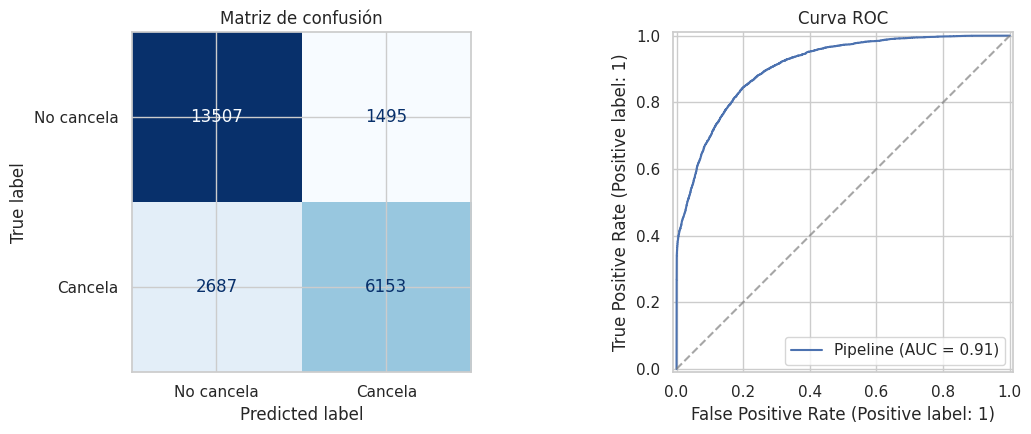

In [3]:
# Matriz de confusión y curva ROC de este modelo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test, ax=ax1,
    display_labels=['No cancela', 'Cancela'], cmap='Blues', colorbar=False)
ax1.set_title('Matriz de confusión')
RocCurveDisplay.from_estimator(modelo, X_test, y_test, ax=ax2)
ax2.plot([0, 1], [0, 1], '--', color='gray', alpha=0.7)
ax2.set_title('Curva ROC')
plt.tight_layout(); plt.show()

## 5. Optimización de hiperparámetros

Buscamos la mejor combinación con **GridSearchCV (búsqueda exhaustiva)**, optimizando **ROC-AUC** por validación cruzada. (Es el mismo procedimiento, por modelo, que automatiza `src/tuning.py` para todo el proyecto.)

In [4]:
from sklearn.model_selection import GridSearchCV

base_pipe = Pipeline([('preprocessor', build_preprocessor()), ('model', LogisticRegression(max_iter=1000, random_state=config.RANDOM_STATE))])
busqueda = GridSearchCV(base_pipe, config.LOGISTIC_REGRESSION_GRID, scoring='roc_auc', cv=config.TUNING_CV_FOLDS, n_jobs=-1)
busqueda.fit(X_train, y_train)
print('Mejores hiperparámetros:', busqueda.best_params_)
print(f'ROC-AUC (validación cruzada, {config.TUNING_CV_FOLDS} folds): {busqueda.best_score_:.4f}')

Mejores hiperparámetros: {'model__C': 10.0, 'model__class_weight': 'balanced'}
ROC-AUC (validación cruzada, 3 folds): 0.9097


## 6. Resultado final y cuándo usar este modelo

Comparamos el rendimiento en test **antes y después** de optimizar:

In [5]:
auc_tuned = evaluar(busqueda.best_estimator_, 'Optimizado')
print(f'\nROC-AUC en test:  base {auc_base:.4f}  ->  optimizado {auc_tuned:.4f}')

Optimizado   | accuracy=0.8211 | precision=0.7333 | recall=0.8132 | f1=0.7712 | roc_auc=0.9077

ROC-AUC en test:  base 0.9072  ->  optimizado 0.9077


**Cuándo conviene:** como **línea base** rápida e interpretable, y cuando esperas que las relaciones sean aproximadamente lineales. Es la referencia contra la que se mide si modelos más complejos merecen la pena.